# Need to make figures like fig 5 in paper but for different N and cost factors

## Imports

In [1]:
import pickle
from utils import *
import numpy as np
from math import e
import matplotlib.pyplot as plt
import pandas as pd
import csv

## Constants

In [2]:
N = 2 ** 24
t = 80
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
cost_factor = 1.5
p = 1 - e **(-2)
n_label = 24

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def get_hashes(m_values):
    # return sum of all elements in m_vaues apart from last one
    return sum(m_values[:-1])

def get_reductions(kis, m_values):
    reductions = []
    for i in range(len(kis) - 1):
        reduction = m_values[i] * kis[i]
        reductions.append(reduction)
    # return sum of all reductions
    return sum(reductions)

## Get vanilla expected mts

In [3]:
expected_mts = []
# mt-max = 2N/t+2
# mt = alpha * mt-max
t = round(log(1-p)/log(1-N**(-1/3)))
mt_max = (2*N)/(t + 2)
for alpha in alphas:
    expected_mts.append(round(alpha * mt_max))

## Optimsie 

Optimization terminated successfully    (Exit mode 0)
            Current function value: -32792.963249243796
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


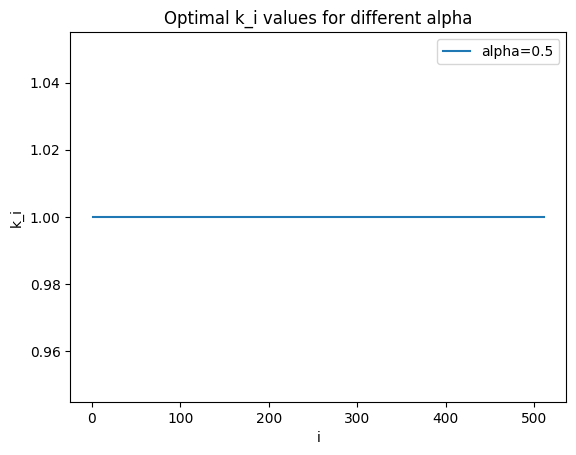

Optimization terminated successfully    (Exit mode 0)
            Current function value: -36080.636883100495
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


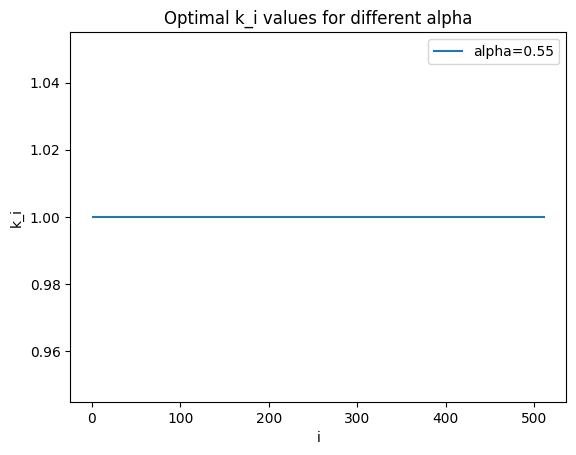

Optimization terminated successfully    (Exit mode 0)
            Current function value: -39369.42563366145
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


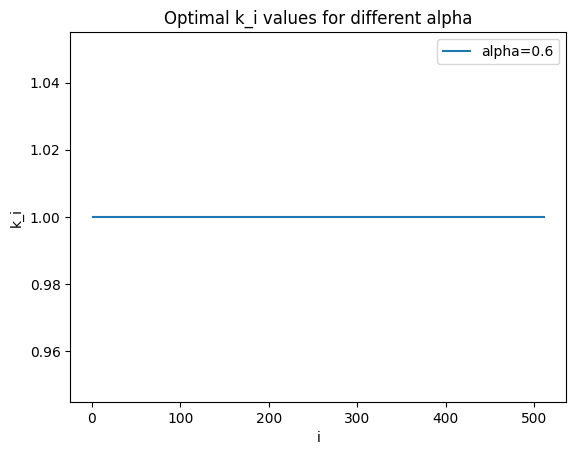

Optimization terminated successfully    (Exit mode 0)
            Current function value: -42659.0343638286
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


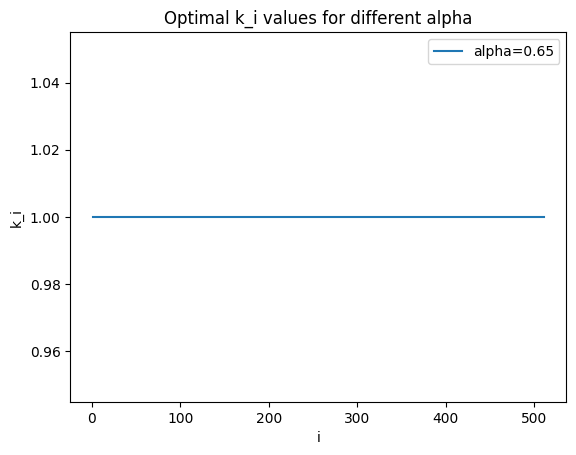

Optimization terminated successfully    (Exit mode 0)
            Current function value: -45949.20118332468
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


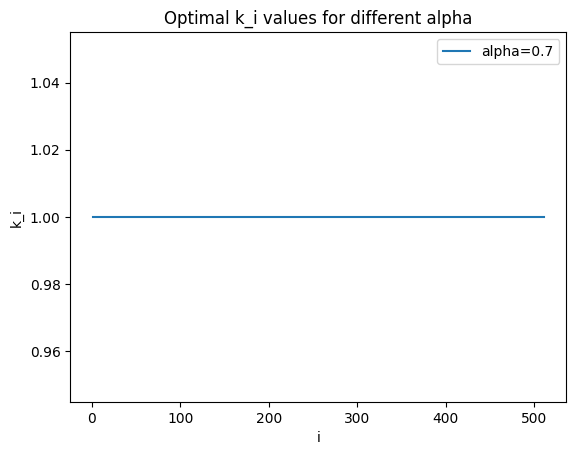

Optimization terminated successfully    (Exit mode 0)
            Current function value: -49239.43747923337
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


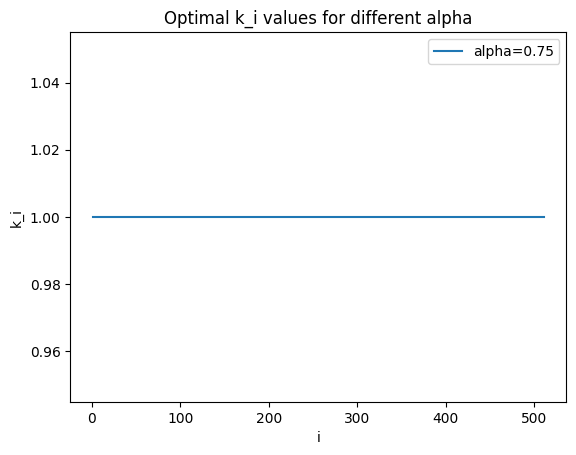

Optimization terminated successfully    (Exit mode 0)
            Current function value: -52528.956228340045
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


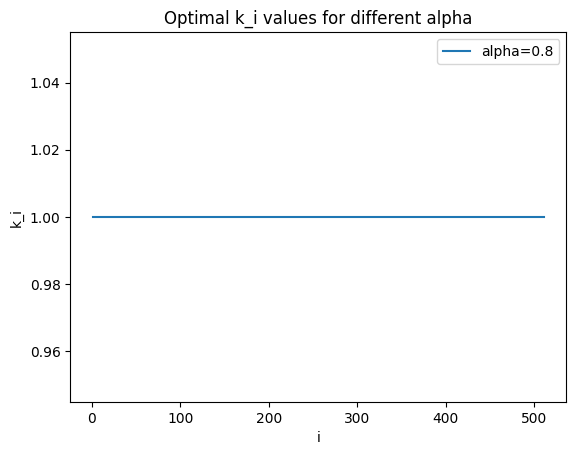

Optimization terminated successfully    (Exit mode 0)
            Current function value: -55816.542594973
            Iterations: 1
            Function evaluations: 512
            Gradient evaluations: 1


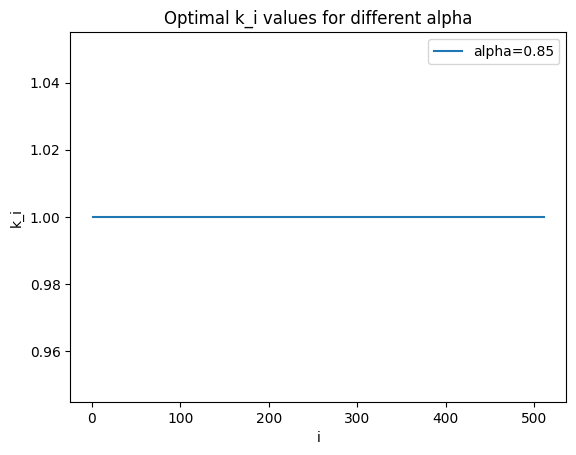

KeyboardInterrupt: 

In [4]:
alpha_kis = []
alpha_m_vals = []
alpha_mts = []
alpha_hashes = []
alpha_reductions = []
# for each alpha
for alpha in alphas:
    kis, m_0, final_cost, m_values = optimise_kj(N, p, alpha, cost_factor, 1, t, 100)
    alpha_kis.append(kis)
    alpha_m_vals.append(m_values)
    alpha_mts.append(m_values[-1])
    alpha_hashes.append(get_hashes(m_values))
    alpha_reductions.append(get_reductions(kis, m_values))

    # plot kis 
    plt.plot(range(1, t + 1), kis, label=f'alpha={alpha}')
    plt.xlabel('i') 
    plt.ylabel('k_i') 
    plt.title('Optimal k_i values for different alpha') 
    plt.legend() 
    plt.show() 

# put into a dataframe
data_cherry = pd.DataFrame({
    'alpha': alphas,
    'optimiser_mt': alpha_mts,
    'vanilla_expected_mt': expected_mts,
    'hashes': alpha_hashes,
    'reductions': alpha_reductions
})

## plot

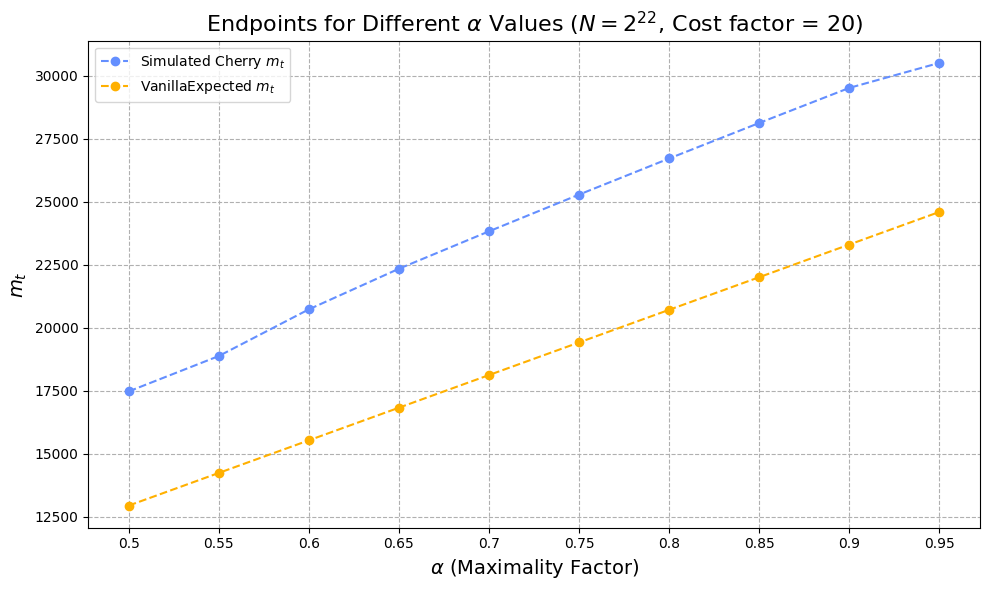

In [ ]:
x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

# plot simulated mt values
plt.plot(x_indicies, data_cherry['optimiser_mt'], color='#648FFF', label='Simulated Cherry $m_t$', linestyle='--', marker='o')

# plot expected mt values
plt.plot(x_indicies, expected_mts, color='#FFB000', label='VanillaExpected $m_t$', linestyle='--', marker='o')

# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title(f'Endpoints for Different $\\alpha$ Values ($N=2^{{{n_label}}}$, Cost factor = {cost_factor})', fontsize=16)

plt.legend()
plt.tight_layout()  
# save as eps
plt.savefig(f'plots/N{n_label}_cf_{cost_factor}.svg', format='svg')
plt.show()

In [ ]:
# don't display the index of the dataframe

display(data_cherry)
# save to a csv file
data_cherry.to_csv(f'plots/N{n_label}_cf_{cost_factor}.csv', index=False)
    

,alpha,optimiser_mt,vanilla_expected_mt,hashes,reductions
0,0.50,17474.737856,12945,6.691548e+06,3.133456e+10
1,0.55,18877.680621,14240,7.625921e+06,2.334920e+10
2,0.60,20730.397980,15534,8.765128e+06,6.360226e+10
3,0.65,22341.309210,16829,9.993644e+06,9.514503e+10
4,0.70,23826.028127,18124,1.137394e+07,1.091631e+11
5,0.75,25283.558711,19418,1.299088e+07,1.257295e+11
6,0.80,26715.921469,20713,1.495158e+07,1.460290e+11
7,0.85,28125.372423,22007,1.745681e+07,1.721803e+11
8,0.90,29516.335112,23302,2.095877e+07,2.090113e+11
9,0.95,30508.500268,24596,2.679345e+07,1.026242e+11
